In [1]:
# %%
import os
import sys
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import json
from harp.clock import decode_harp_clock, align_timestamps_to_anchor_points
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
from utils.beh_functions import parseSessionID, session_dirs, get_unit_tbl
from utils.plot_utils import shiftedColorMap, template_reorder, get_gradient_colors
from utils.opto_utils import opto_metrics
from open_ephys.analysis import Session
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.postprocessing as spost
import spikeinterface.widgets as sw
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import load_nwb
from aind_ephys_utils import align
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from matplotlib import colormaps
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from spikeinterface.core.sorting_tools import random_spikes_selection
import pickle
import shutil
import datetime
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.postprocessing as spost
from tqdm import tqdm
import spikeinterface.widgets as sw
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from trimesh import load_mesh
from utils.ccf_utils import ccf_pts_convert_to_mm
from matplotlib.gridspec import GridSpec as gs
from scipy.signal import welch
from utils.plot_utils import combine_pdf_big
import numbers
%matplotlib inline

In [13]:
session = 'behavior_838332_2026-03-10_13-23-52'
data_type = 'raw'
target = 'soma'

session_dir = session_dirs(session)
session_dir

{'aniID': '838332',
 'raw_id': '838332_2026-03-10_13-23-52',
 'datetime': datetime.datetime(2026, 3, 10, 13, 23, 52),
 'raw_dir': '/root/capsule/data/behavior_838332_2026-03-10_13-23-52_raw_data',
 'raw_rec': '/root/capsule/data/behavior_838332_2026-03-10_13-23-52_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#Neuropix-PXI-100.ProbeA.zarr',
 'session_dir': '/root/capsule/data/behavior_838332_2026-03-10_13-23-52_raw_data/ecephys/ecephys_clipped',
 'session_dir_raw': '/root/capsule/data/behavior_838332_2026-03-10_13-23-52_raw_data/ecephys/ecephys_compressed',
 'processed_dir': '/root/capsule/scratch/838332/behavior_838332_2026-03-10_13-23-52',
 'alignment_dir': '/root/capsule/scratch/838332/behavior_838332_2026-03-10_13-23-52/alignment',
 'beh_fig_dir': '/root/capsule/scratch/838332/behavior_838332_2026-03-10_13-23-52/behavior',
 'ephys_dir_raw': '/root/capsule/scratch/838332/behavior_838332_2026-03-10_13-23-52/ephys/raw',
 'ephys_processed_dir_raw': '/root/capsule/scrat

In [14]:
if session_dir['surface_rec'] is not None:
    surface = True
else:
    surface = False

# detect if there's mapping
# load the LFP data 
recording_zarr = session_dir['raw_rec']
recording = si.read_zarr(recording_zarr)
channel_locs = recording.get_channel_locations()[:,1] + 0.5*recording.get_channel_locations()[:,0]/32  # y + depth/2
#recording = recording.select_segments(session_dir['seg_id']-1)
#recording_LFP = spre.bandpass_filter(recording, freq_min=1, freq_max=300)
#recording_LFP = spre.common_reference(recording_LFP, reference='global', operator='median')
if surface:
    recording_zarr_surface = session_dir['surface_rec']
    recording_surface = si.read_zarr(recording_zarr_surface)
    channel_locs_surface = recording_surface.get_channel_locations()[:,1] + 0.5*recording_surface.get_channel_locations()[:,0]/32
    #recording_surface = recording_surface.select_segments(session_dir['surface_seg_id']-1)
    #recording_LFP_surface = spre.bandpass_filter(recording_surface, freq_min=1, freq_max=300)
    #recording_LFP_surface = spre.common_reference(recording_LFP_surface, reference='global', operator='median')

channel_locs[-20:]


array([2730. , 2730.5, 2745. , 2745.5, 2760. , 2760.5, 2775. , 2775.5,
       2790. , 2790.5, 2805. , 2805.5, 2820. , 2820.5, 2835. , 2835.5,
       2850. , 2850.5, 2865. , 2865.5])

In [16]:
channel_locs_surface[:20]

array([2880. , 2940.5, 2985. , 3045.5, 3090. , 2910.5, 2955. , 3015.5,
       3060. , 2880.5, 2925. , 2985.5, 3030. , 3090.5, 2895. , 2955.5,
       3000. , 3060.5, 3105. , 2925.5])

In [3]:
unit_tbl = get_unit_tbl(session, data_type)

Single experiment found: experiment1, recording1


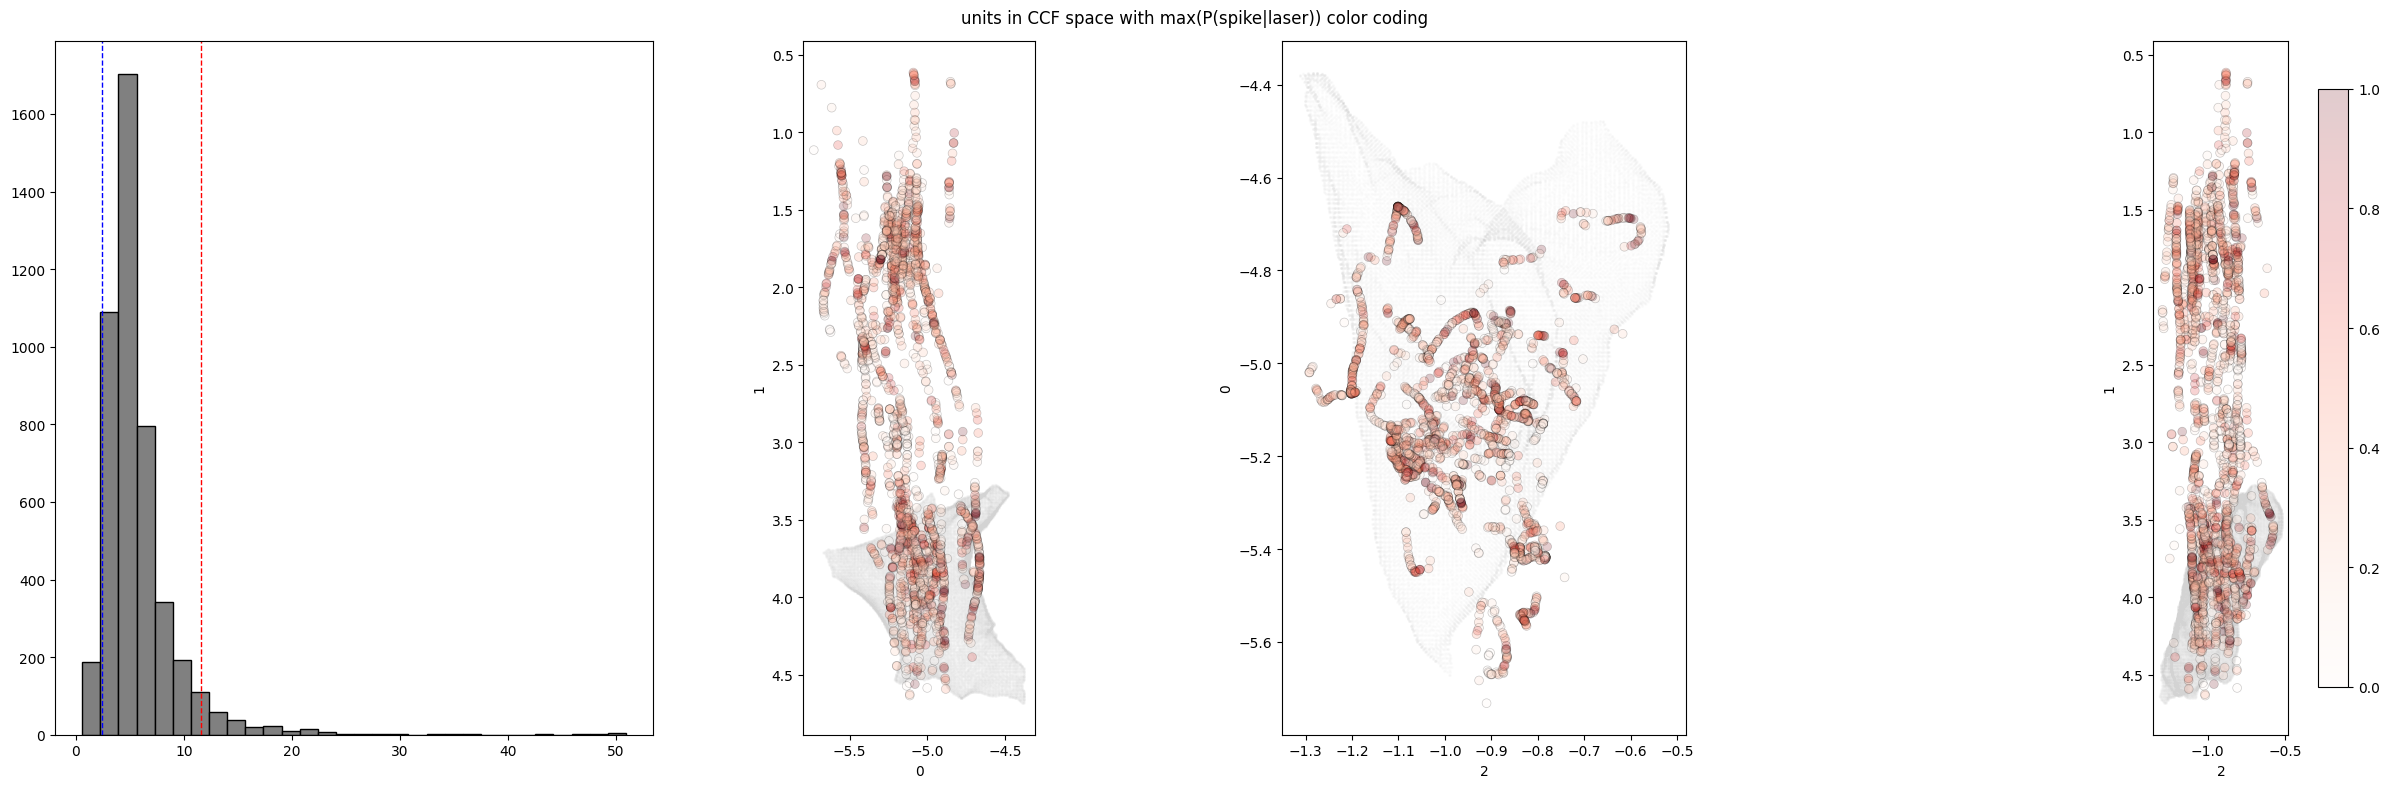

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
features = ['amp', 'firing_rate']
color_code_filtered = combined_tagged_units_filtered['snr'].values
ax = axes[0]
# Plot histogram of color code
ax.hist(color_code_filtered[~np.isnan(color_code_filtered)], bins=30, color='gray', edgecolor='black')
top_90 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.95)
bottom_10 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.05)
ax.axvline(top_90, color='red', linestyle='--', linewidth=1)
ax.axvline(bottom_10, color='blue', linestyle='--', linewidth=1)
color_code_nl = color_code_filtered.copy()
# color_code_nl = (color_code_nl - 0) / (np.nanmax(color_code_filtered)-0)  # Normalize color code to [0, 1] using 10-90% quantiles
color_code_nl = (color_code_nl - bottom_10) / (top_90 - bottom_10)  # Normalize color code to [0, 1] using 10-90% quantile
color_code_nl[color_code_nl < 0] = 0
color_code_nl[color_code_nl > 1] = 1
x_ccf = combined_tagged_units_filtered['x_ccf'].values
y_ccf = combined_tagged_units_filtered['y_ccf'].values
z_ccf = combined_tagged_units_filtered['z_ccf'].values
ccfs = np.column_stack((x_ccf, y_ccf, z_ccf))
ccfs = ccf_pts_convert_to_mm(ccfs)
ccfs[:, 2] = -np.abs(ccfs[:, 2])  # Mirror ML to left
for plane, ax in zip(planes.keys(), axes[1:]):
    # Plot the mesh
    ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
    # Plot the points
    sc = ax.scatter(ccfs[:, planes[plane][0]], ccfs[:, planes[plane][1]], c=color_code_nl, cmap='Reds', s=40, alpha=0.2, edgecolors='black', linewidths=0.5)
    # if plane == 'hor':
    #     ax.set_title(feature)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)
plt.suptitle(f'units in CCF space with max(P(spike|laser)) color coding')
plt.tight_layout()
plt.savefig(f'/root/capsule/scratch/combined/ccf_maps/{animal_id}_units_ccf_opto_tag.png', dpi=300)

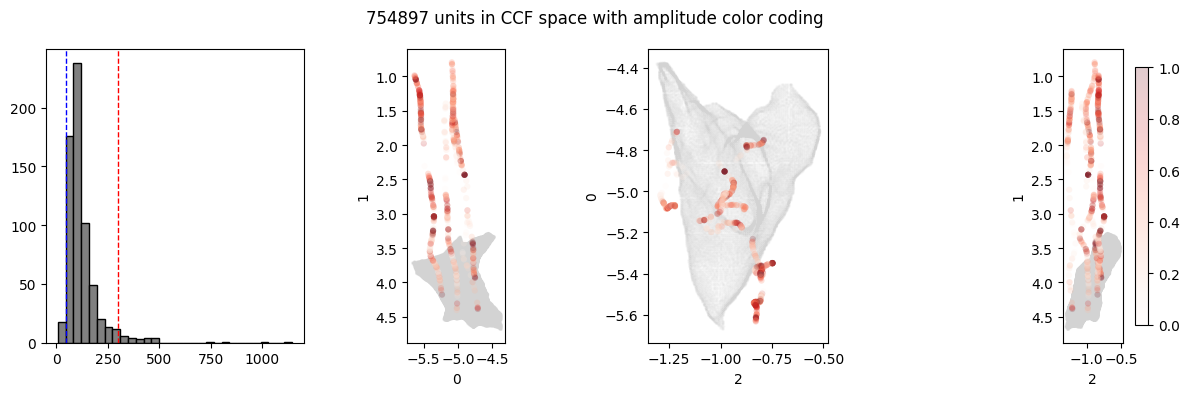

In [77]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
features = ['amp', 'firing_rate']
color_code_filtered = combined_tagged_units_filtered['amp'].values
ax = axes[0]
# Plot histogram of color code
ax.hist(color_code_filtered[~np.isnan(color_code_filtered)], bins=30, color='gray', edgecolor='black')
# top_90 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.95)
# bottom_10 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.05)
# ax.axvline(top_90, color='red', linestyle='--', linewidth=1)
# ax.axvline(bottom_10, color='blue', linestyle='--', linewidth=1)
color_code_nl = color_code_filtered.copy()
color_code_nl = (color_code_nl - 50) / (200-50)  # Normalize color code to [0, 1] using 10-90% quantiles
color_code_nl[color_code_nl < 0] = 0
color_code_nl[color_code_nl > 1] = 1
ax.axvline(50, color='blue', linestyle='--', linewidth=1)
ax.axvline(300, color='red', linestyle='--', linewidth=1)
x_ccf = combined_tagged_units_filtered['x_ccf'].values
y_ccf = combined_tagged_units_filtered['y_ccf'].values
z_ccf = combined_tagged_units_filtered['z_ccf'].values
ccfs = np.column_stack((x_ccf, y_ccf, z_ccf))
ccfs = ccf_pts_convert_to_mm(ccfs)
ccfs[:, 2] = -np.abs(ccfs[:, 2])  # Mirror ML to left
for plane, ax in zip(planes.keys(), axes[1:]):
    # Plot the mesh
    ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.2)
    # Plot the points
    sc = ax.scatter(ccfs[:, planes[plane][0]], ccfs[:, planes[plane][1]], c=color_code_nl, cmap='Reds', s=20, edgecolor='none', alpha=0.2)
    # if plane == 'hor':
    #     ax.set_title(feature)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)
plt.suptitle(f'{animal_id} units in CCF space with amplitude color coding')
plt.tight_layout()

NameError: name 'combined_tagged_units_filtered' is not defined

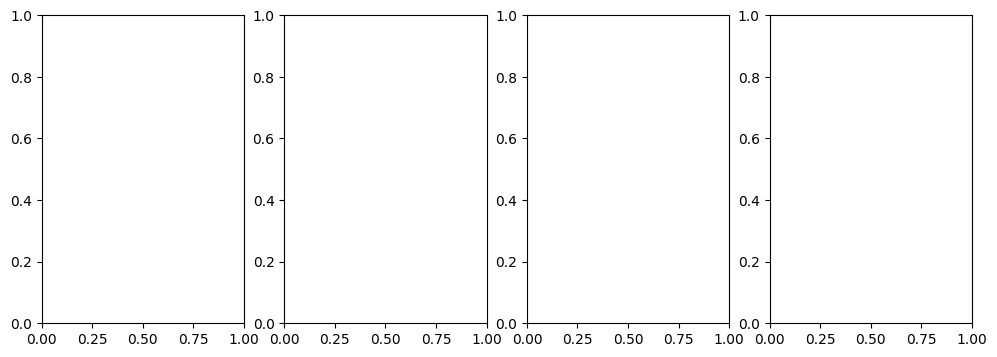

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
color_code_filtered = combined_tagged_units_filtered['fr'].values
ax = axes[0]
# Plot histogram of color code
ax.hist(color_code_filtered[~np.isnan(color_code_filtered)], bins=30, color='gray', edgecolor='black')
# top_90 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.95)
# bottom_10 = np.quantile(color_code_filtered[~np.isnan(color_code_filtered)], 0.05)
# ax.axvline(top_90, color='red', linestyle='--', linewidth=1)
# ax.axvline(bottom_10, color='blue', linestyle='--', linewidth=1)
color_code_nl = color_code_filtered.copy()
color_code_nl = (color_code_nl - 0) / (10)  # Normalize color code to [0, 1] using 10-90% quantiles
color_code_nl[color_code_nl < 0] = 0
color_code_nl[color_code_nl > 1] = 1
x_ccf = combined_tagged_units_filtered['x_ccf'].values
y_ccf = combined_tagged_units_filtered['y_ccf'].values
z_ccf = combined_tagged_units_filtered['z_ccf'].values
ccfs = np.column_stack((x_ccf, y_ccf, z_ccf))
ccfs = ccf_pts_convert_to_mm(ccfs)
ccfs[:, 2] = -np.abs(ccfs[:, 2])  # Mirror ML to left
for plane, ax in zip(planes.keys(), axes[1:]):
    # Plot the mesh
    ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.2)
    # Plot the points
    sc = ax.scatter(ccfs[:, planes[plane][0]], ccfs[:, planes[plane][1]], c=color_code_nl, cmap='Reds', s=20, edgecolor='none', alpha=0.2)
    # if plane == 'hor':
    #     ax.set_title(feature)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)
plt.suptitle(f'{animal_id} units in CCF space with firing rate color coding')
plt.tight_layout()

/opt/conda/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 8096 is greater than input length  = 5000, using nperseg = 5000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/opt/conda/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 8096 is greater than input length  = 1500, using nperseg = 1500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


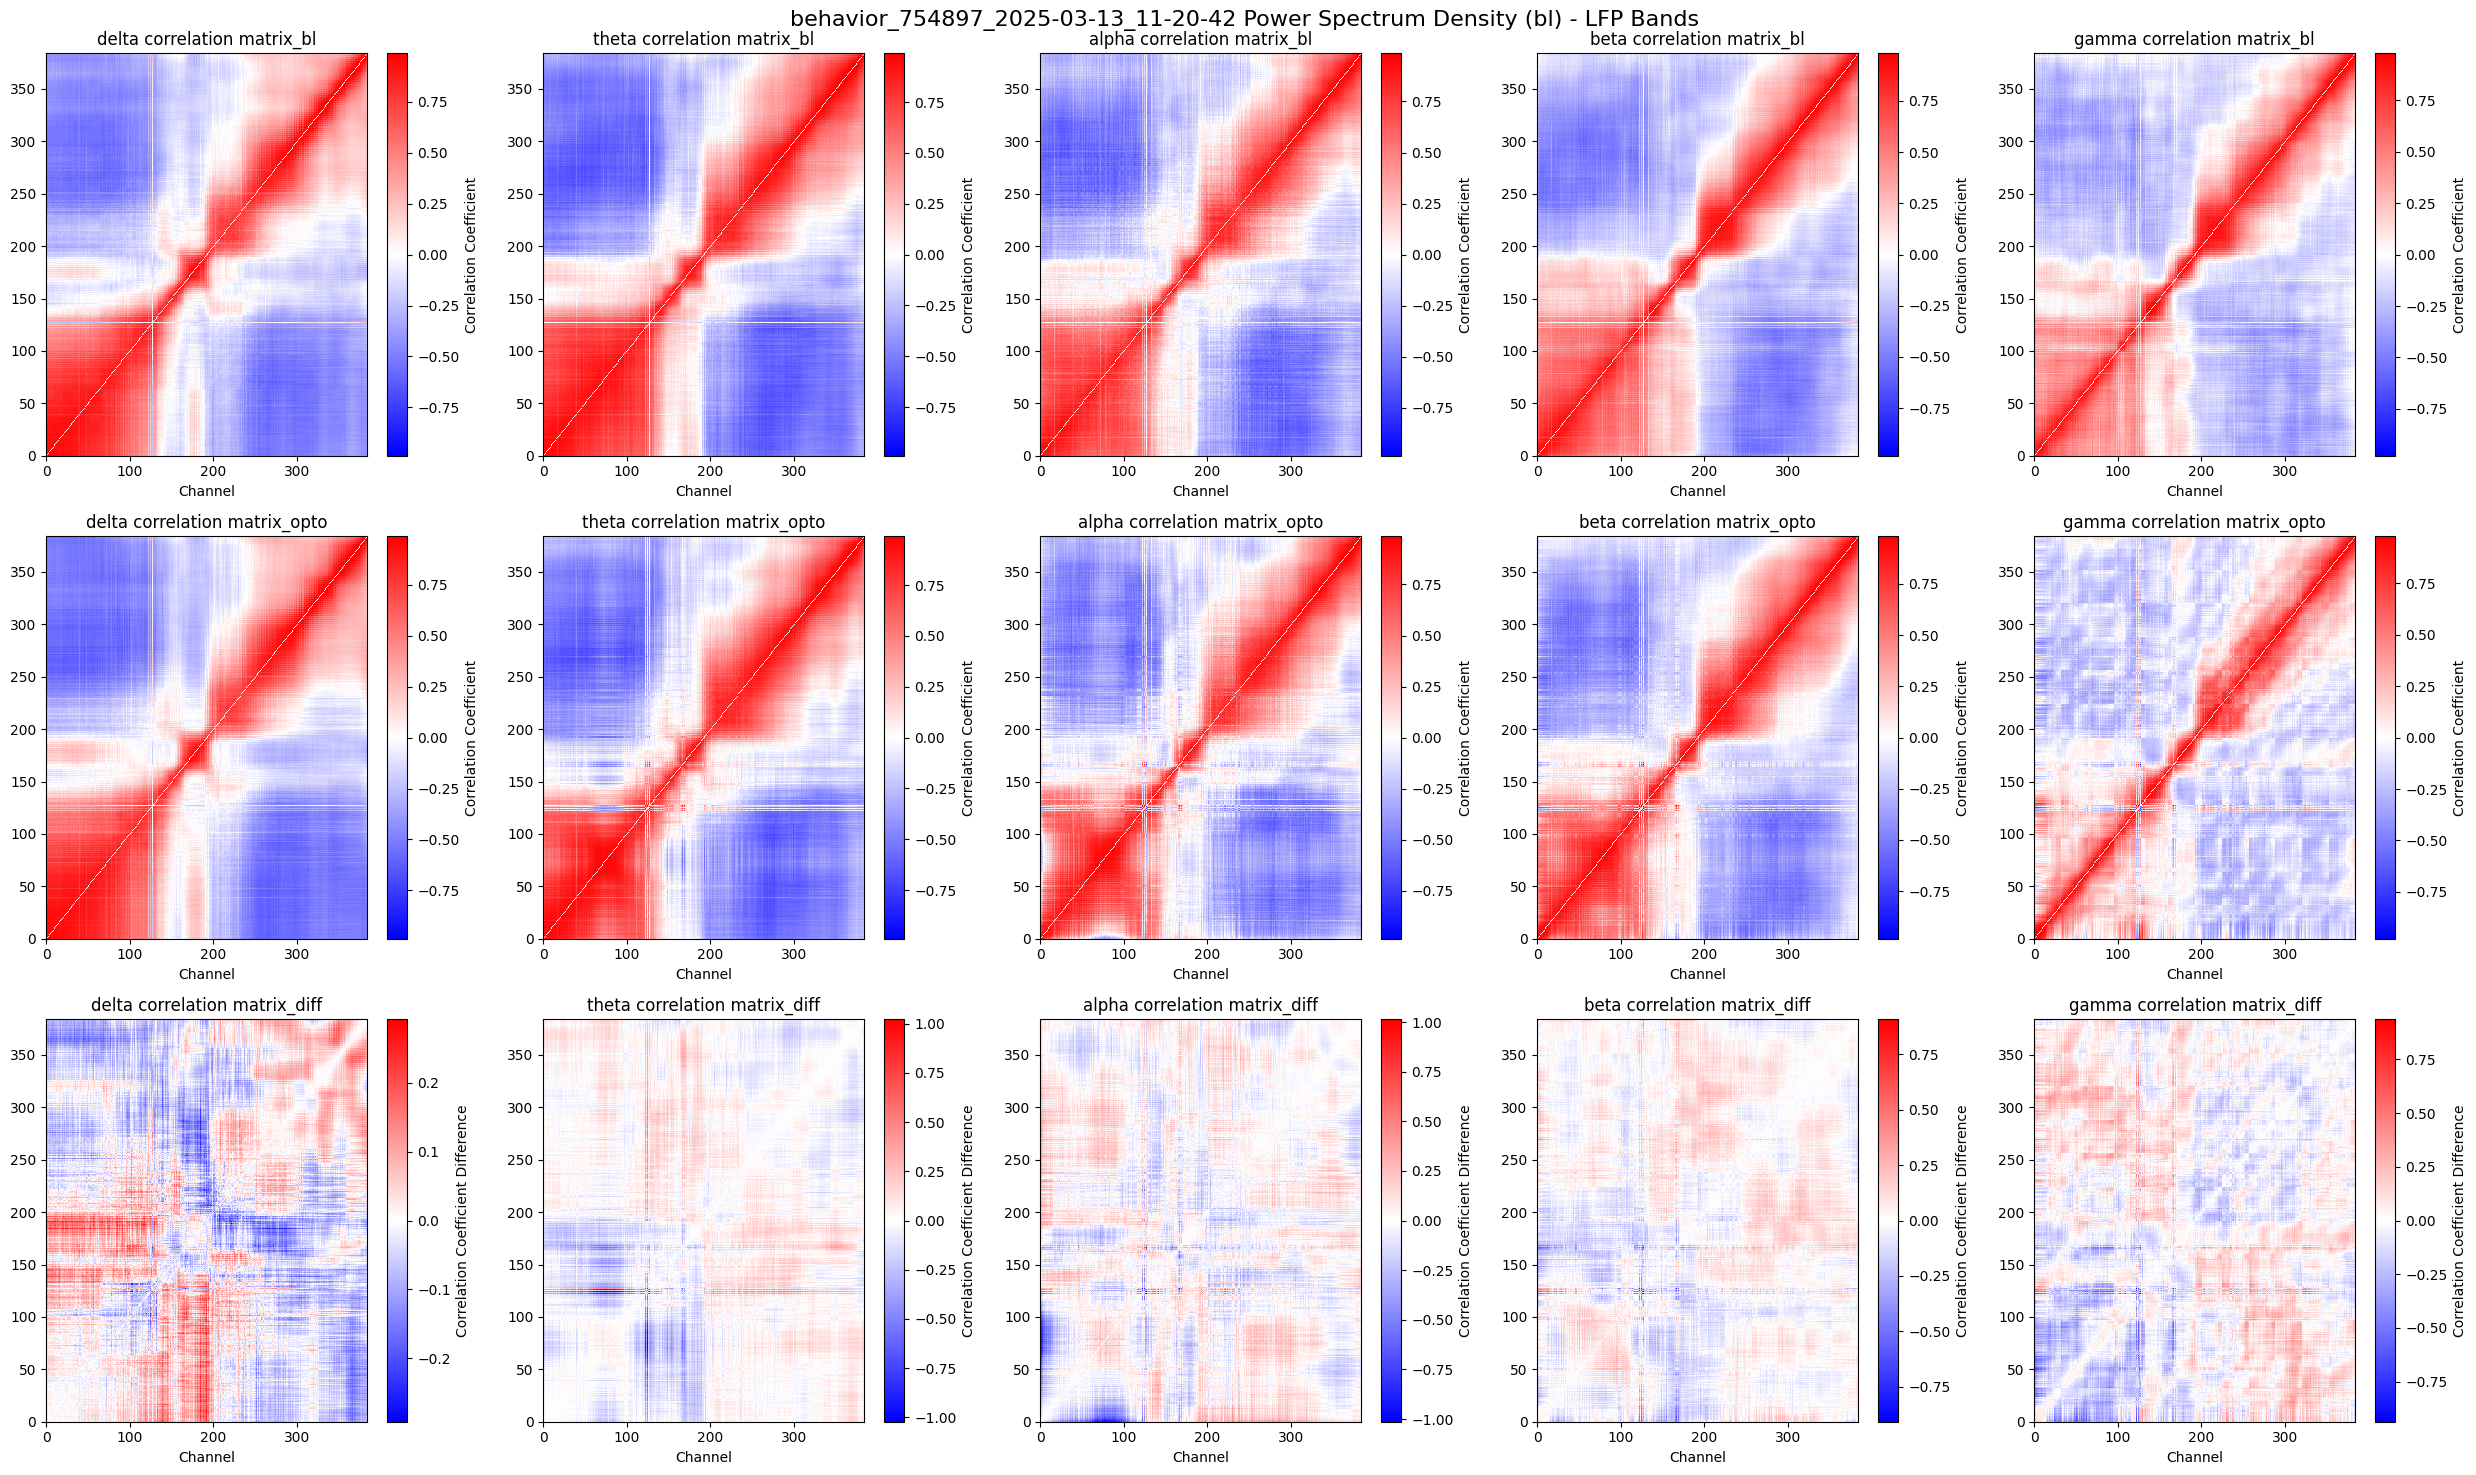

In [11]:
plot_ephys_corr_band(session, probe='2', data_type='curated')

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

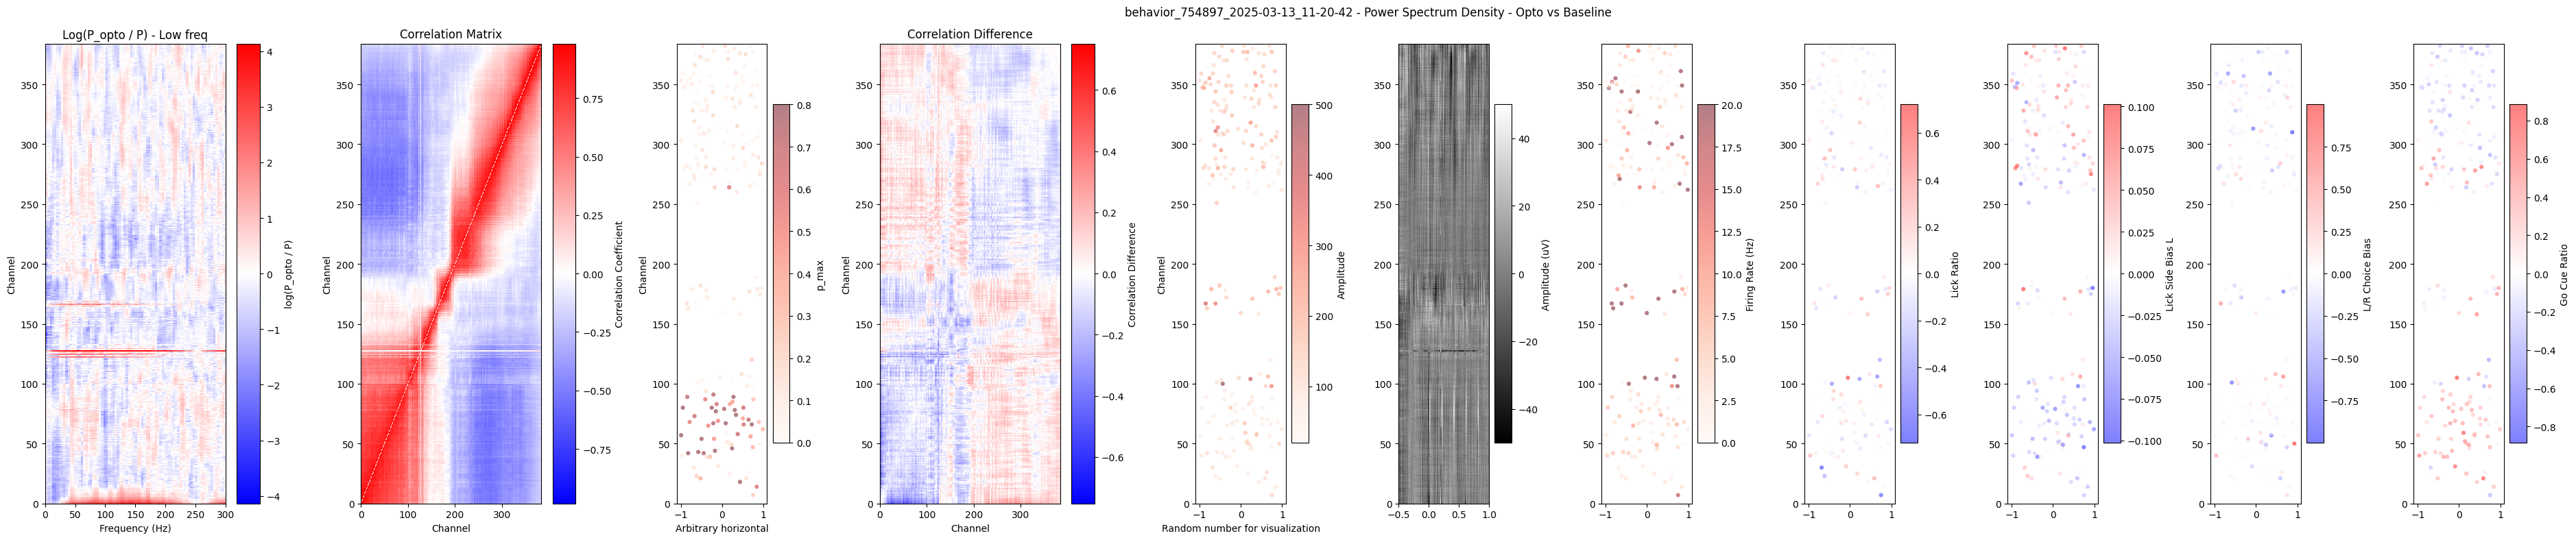

In [41]:
plot_ephys_probe('behavior_754897_2025-03-13_11-20-42', data_type='curated', probe='2')

In [ ]:
session_assets = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')
session_list = session_assets['session_id']
probe_list = session_assets['probe']
probe_list = [probe for probe, session in zip(probe_list, session_list) if isinstance(session, str)]
session_list = [session for session in session_list if isinstance(session, str)]    
from joblib import Parallel, delayed
data_type = 'curated'
def process(session, data_type, probe): 
    print(f'Starting {session}')
    session_dir = session_dirs(session)
    # if os.path.exists(os.path.join(session_dir['beh_fig_dir'], f'{session}.nwb')):
    print(session_dir[f'curated_dir_{data_type}'])
    if session_dir[f'curated_dir_{data_type}'] is not None:
        try:
            # plot_ephys_probe(session, data_type=data_type, probe=probe) 
            plot_ephys_corr_band(session, 
                    data_type='curated', 
                    probe = probe)
            plt.close('all')
            print(f'Finished {session}')
        except:
            print(f'Error processing {session}')
            plt.close('all')
    else: 
        print(f'No curated data found for {session}') 
    # elif session\_dir['curated_dir_raw'] is not None:
    #     data_type = 'raw' 
    #     opto_tagging_df_sess = opto_plotting_session(session, data_type, target, resp_thresh=resp_thresh, lat_thresh=lat_thresh, target_unit_ids= None, plot = True, save=True)
# Parallel(n_jobs=3)(delayed(process)(session, data_type, probe) for session, probe in zip(session_list, probe_list))
# # process('behavior_754897_2025-03-13_11-20-42', data_type)
# for session, probe in zip(session_list, probe_list):
#     process(session, data_type, probe)
#     plt.close('all')

In [8]:
# move all psd mean and opto to ephys_combined folder's subfolders mean and opto
session_assets = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')
session_list = session_assets['session_id'][-9:]
session_list = [session for session in session_list if isinstance(session, str)]   

bl_dir = '/root/capsule/scratch/combined/ephys_combined/bl'
opto_dir = '/root/capsule/scratch/combined/ephys_combined/opto'
cmp_dir = '/root/capsule/scratch/combined/ephys_combined/compare'
band_corr_dir = '/root/capsule/scratch/combined/ephys_combined/band_corr'
# shutil.rmtree(path=bl_dir, ignore_errors=True)
# shutil.rmtree(path=opto_dir, ignore_errors=True)
# shutil.rmtree(path=cmp_dir, ignore_errors=True)
# shutil.rmtree(path=band_corr_dir, ignore_errors=True)
# os.mkdir(path=bl_dir)
# os.mkdir(path=opto_dir)
# os.mkdir(path=cmp_dir)
# os.mkdir(path=band_corr_dir)

data_type = 'curated'
for session in session_list:
    session_dir = session_dirs(session)
    if os.path.exists(os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_power_spectrum_density_bl.png')):
        print(f'Processing {session}...')
        # curr_file = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_power_spectrum_density_bl.png')
        # target_file = os.path.join(bl_dir, f'{session}_bl.png')
        # shutil.copy(curr_file, target_file)

        # curr_file = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_power_spectrum_density_opto.png')
        # target_file = os.path.join(opto_dir, f'{session}_opto.png')
        # shutil.copy(curr_file, target_file)
        
        # curr_file = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_power_spectrum_density_opto_vs_baseline.png')
        # target_file = os.path.join(cmp_dir, f'{session}_opto_vs_baseline.png')
        # shutil.copy(curr_file, target_file)

        curr_file = os.path.join(os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_cross_corr_LFP_bands.png'))
        target_file = os.path.join(band_corr_dir, f'{session}_cross_corr_LFP_bands.png')
        shutil.copy(curr_file, target_file)
    else:
        print(f'Skipping {session} as it does not have the required files')
        

Single experiment found: experiment1, recording1
Skipping behavior_784806_2025-06-17_14-59-23 as it does not have the required files
Single experiment found: experiment1, recording1
Skipping behavior_784806_2025-06-18_13-39-50 as it does not have the required files
Single experiment found: experiment1, recording1
Skipping behavior_784806_2025-06-20_13-39-16 as it does not have the required files
Selected experiment1 recording1, length:4862.23
Skipping behavior_791691_2025-06-24_13-21-29 as it does not have the required files
Selected experiment1 recording1, length:3910.93
Skipping behavior_791691_2025-06-25_14-06-10 as it does not have the required files
Selected experiment1 recording1, length:4926.98
Skipping behavior_791691_2025-06-26_13-39-26 as it does not have the required files
Selected experiment1 recording1, length:4500.67


ValueError: attempt to get argmax of an empty sequence

In [9]:
os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_power_spectrum_density_bl.png')

'/root/capsule/scratch/791691/behavior_791691_2025-06-26_13-39-26/ephys/curated/figures/behavior_791691_2025-06-27_13-54-30_power_spectrum_density_bl.png'

In [46]:
combine_pdf_big(opto_dir, os.path.join('/root/capsule/scratch/combined/ephys_combined', 'opto_combined.pdf'))
combine_pdf_big(bl_dir, os.path.join('/root/capsule/scratch/combined/ephys_combined', 'bl_combined.pdf'))
combine_pdf_big(cmp_dir, os.path.join('/root/capsule/scratch/combined/ephys_combined', 'compare_combined.pdf'))
combine_pdf_big(band_corr_dir, os.path.join('/root/capsule/scratch/combined/ephys_combined', 'band_corr_combined.pdf'))

Processing 67 files in /root/capsule/scratch/combined/ephys_combined/opto
Combined PDF saved as: /root/capsule/scratch/combined/ephys_combined/opto_combined.pdf
Processing 67 files in /root/capsule/scratch/combined/ephys_combined/bl
Combined PDF saved as: /root/capsule/scratch/combined/ephys_combined/bl_combined.pdf
Processing 67 files in /root/capsule/scratch/combined/ephys_combined/compare
Combined PDF saved as: /root/capsule/scratch/combined/ephys_combined/compare_combined.pdf
Processing 67 files in /root/capsule/scratch/combined/ephys_combined/band_corr
Combined PDF saved as: /root/capsule/scratch/combined/ephys_combined/band_corr_combined.pdf


In [10]:
# plot LFP after opto stimulation
session = 'behavior_754897_2025-03-13_11-20-42'
session_dir = session_dirs(session)
data_type = 'curated'
probe = '2.0'
ili_thresh = 1

unit_tbl = get_unit_tbl(session, data_type)
nwb = load_nwb_from_filename(session_dir['nwb_beh'])
lick_L = nwb.acquisition['left_lick_time'].timestamps[:]
lick_R = nwb.acquisition['right_lick_time'].timestamps[:]
# combine L and R
licks = np.concatenate((lick_L, lick_R))
licks = np.sort(licks, axis=0)

# find train starts
train_starts = licks[np.where(np.diff(licks) > ili_thresh)[0] + 1]
lick_ratio = np.full(len(curr_unit_tbl), np.nan, dtype=float)

for unit_ind, unit in enumerate(curr_unit_tbl['unit'].values):
    spike_times = unit_tbl[unit_tbl['unit_id'] == unit]['spike_times'].values[0]
    df_bl = align.to_events(spike_times, train_starts, (-1, 0), return_df=True)
    df_lick = align.to_events(spike_times, train_starts, (0, 0.5), return_df=True)
    bl_counts = np.zeros(len(train_starts))
    resp_counts = np.zeros(len(train_starts))
    for i in range(len(train_starts)):
        bl_counts[i] = len(df_bl[df_bl['event_index'] == i])/1
        resp_counts[i] = len(df_lick[df_lick['event_index'] == i])/0.5
    lick_ratio[unit_ind] = np.mean((resp_counts-bl_counts) / (resp_counts + bl_counts + 1e-6))

FileNotFoundError: /root/capsule/scratch/784803/behavior_784803_2025-07-03/behavior/behavior_784803_2025-07-03.nwb

In [4]:
session_assets = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')
session_list = session_assets['session_id']
session_list = [session for session in session_list if isinstance(session, str)]   

In [14]:
session_dirs('behavior_791691_2025-06-27_13-54-30')

Selected experiment1 recording1, length:4500.67


ValueError: attempt to get argmax of an empty sequence

In [6]:
tar_folder = '/root/capsule/scratch/combined/ephys_combined/band_corr'
data_type = 'curated'
for ind, session in enumerate(session_list[-9:]):
    print(session)
    session_dir = session_dirs(session)
    # if session_dir['curated_dir_curated'] is not None:
    #     data_type = 'curated'
    # elif session_dir['curated_dir_raw'] is not None:
    #     data_type = 'raw'
    # else:
    #     print(f'Skipping {session} as it does not have curated or raw data.')
    #     continue
    # # copy data
    curr_tar_dir = os.path.join(tar_folder, session, 'ProbeA', 'band_corr')
    os.makedirs(curr_tar_dir, exist_ok=True)    
    source_dir = os.path.join(session_dir[f'ephys_processed_dir_{data_type}'], 'band_corr')
    if not os.path.exists(source_dir):
        print(f'Skipping {session} as it does not have the required files')
        continue
    shutil.copytree(source_dir, curr_tar_dir, dirs_exist_ok=True)
    # copy figs
    curr_tar_dir = os.path.join(tar_folder, f'{session}_cross_corr_LFP_bands.png')
    source_dir = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_cross_corr_LFP_bands.png')
    if not os.path.exists(source_dir):
        print(f'Skipping {session} as it does not have the required figures.')
        continue
    shutil.copy(source_dir, curr_tar_dir)

behavior_784806_2025-06-17_14-59-23
Single experiment found: experiment1, recording1
behavior_784806_2025-06-18_13-39-50
Single experiment found: experiment1, recording1
behavior_784806_2025-06-20_13-39-16
Single experiment found: experiment1, recording1
behavior_791691_2025-06-24_13-21-29
Selected experiment1 recording1, length:4862.23
behavior_791691_2025-06-25_14-06-10
Selected experiment1 recording1, length:3910.93
behavior_791691_2025-06-26_13-39-26
Selected experiment1 recording1, length:4926.98
behavior_791691_2025-06-27_13-54-30
Selected experiment1 recording1, length:4500.67
behavior_784803_2025-07-01_13-58-26
Selected experiment1 recording1, length:4097.49
behavior_784803_2025-07-02_13-41-41
Selected experiment1 recording1, length:4350.40


In [11]:
source_dir

'/root/capsule/scratch/791691/behavior_791691_2025-06-26_13-39-26/ephys/curated/figures/behavior_784803_2025-07-02_13-41-41_cross_corr_LFP_bands.png'

In [6]:
tar_folder = '/root/capsule/scratch/combined/ephys_combined/band_corr'
# data_type = 'raw'
for ind, session in enumerate(session_list):
    session_dir = session_dirs(session)
    # if session_dir['curated_dir_curated'] is not None:
    #     data_type = 'curated'
    # elif session_dir['curated_dir_raw'] is not None:
    #     data_type = 'raw'
    # else:
    #     print(f'Skipping {session} as it does not have curated or raw data.')
        # continue
    data_type = 'raw'
    # copy data
    # unit_tbl
    unit_tbl = get_unit_tbl(session, data_type)
    if unit_tbl is not None:
        if 'p_max' in unit_tbl.columns:
            print(f'Making custom data for {session}')
            custom_metrics = unit_tbl[['unit_id', 'p_max']]
            custom_metrics = custom_metrics.rename(columns={'unit_id': 'cluster_id', 'p_max': 'p_response'})
            curr_tar_dir = os.path.join(tar_folder, session, 'ProbeA', 'custom_metrics')
            os.makedirs(curr_tar_dir, exist_ok=True)    
            custom_metrics.to_csv(os.path.join(curr_tar_dir, 'custom_metrics.csv'))
            # source_dir = os.path.join(session_dir[f'ephys_processed_dir_{data_type}'], 'band_corr')
            # if not os.path.exists(source_dir):
            #     print(f'Skipping {session} as it does not have the required files')
            #     continue
            # shutil.copytree(source_dir, curr_tar_dir, dirs_exist_ok=True)
            # # copy figs
            # curr_tar_dir = os.path.join(tar_folder, f'{session}_cross_corr_LFP_bands.png')
            # source_dir = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], f'{session}_cross_corr_LFP_bands.png')
            # if not os.path.exists(source_dir):
            #     print(f'Skipping {session} as it does not have the required figures.')
            #     continue
            # shutil.copy(source_dir, curr_tar_dir)

Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_713854_2024-03-05_12-01-40
Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_713854_2024-03-05_13-01-09
Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_713854_2024-03-05_13-31-20
Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_717120_2024-03-06_12-23-53
Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_717120_2024-03-06_12-54-27
Single experiment found: experiment1, recording1
Single experiment found: experiment1, recording1
Making custom data for ecephys_717120_2024-03-07_12-12-02
Selected experiment1 recording1, length:926.72
Selected experime

In [19]:
custom_metrics = custom_metrics.rename(columns={'unit_id': 'cluster_id', 'p_max': 'p_response'})
custom_metrics

,cluster_id,p_response
0,0,0.067565
1,1,0.133974
2,2,-0.095125
3,3,0.030265
4,4,0.113496
...,...,...
119,123,0.068006
120,124,0.045502
121,125,0.124045
122,126,0.027428


In [3]:
metrics_file = '/root/capsule/data/SmartSPIM_751766_2025-04-08_17-56-45_ibl-converted_2025-09-08_14-17-00/751766/behavior_751766_2025-02-11_11-53-32/ProbeA/clusters.metrics.csv'
metrics = pd.read_csv(metrics_file)
depth_file = '/root/capsule/data/SmartSPIM_751766_2025-04-08_17-56-45_ibl-converted_2025-09-08_14-17-00/751766/behavior_751766_2025-02-11_11-53-32/ProbeA/clusters.channels.npy'
depth = np.load(depth_file)
metrics['depth'] = depth

In [4]:
metrics

,cluster_id,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,...,silhouette,sliding_rp_violation,snr,sync_spike_2,sync_spike_4,sync_spike_8,cluster_id.1,default_qc,unitrefine_label,depth
0,0,0.000902,0.300496,0.965847,-61.425000,NaN,NaN,NaN,NaN,1.80,...,NaN,NaN,3.904371,0.102217,0.028393,0.021066,0,False,noise,6
1,1,0.000083,0.315307,0.341130,-59.670000,5.622157,48.762669,194.953590,68.807312,4.20,...,0.052724,0.215,3.680087,0.052685,0.003219,0.002748,1,False,mua,22
2,2,0.000209,0.352353,0.393490,-51.480000,4.190416,0.000000,0.000000,0.000000,2.60,...,0.051988,0.090,3.120048,0.064283,0.013135,0.009395,2,True,mua,24
3,4,0.000010,NaN,NaN,-9.360000,5.379566,67.890355,240.000000,96.432712,61.88,...,0.118060,0.005,0.583838,0.047274,0.000785,0.000558,4,True,sua,31
4,5,0.000029,NaN,NaN,-124.020000,7.553711,5.909501,34.400482,6.376970,19.48,...,0.126446,0.010,6.748741,0.052508,0.001258,0.000772,5,True,sua,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,278,0.000238,0.285321,0.234814,-62.594997,2.666538,NaN,NaN,NaN,0.80,...,0.020395,NaN,4.781142,0.072633,0.008431,0.001946,278,False,mua,272
276,279,NaN,NaN,NaN,-30.127499,3.060583,NaN,NaN,NaN,0.40,...,0.093937,NaN,1.612954,0.046256,0.000000,0.000000,279,False,noise,170
277,280,0.020150,0.278299,0.353414,-88.920000,4.103879,NaN,NaN,NaN,0.60,...,0.146938,NaN,5.113240,0.066242,0.000000,0.000000,280,True,noise,180
278,281,0.003573,0.609832,0.305807,-39.780000,2.019275,NaN,NaN,NaN,0.40,...,0.014046,NaN,2.577190,0.080745,0.001553,0.000000,281,True,noise,182


In [33]:
filter = (metrics['unitrefine_label']!= 'noise') & (metrics['unitrefine_label'] != 'artifact')

Text(0, 0.5, 'Channel')

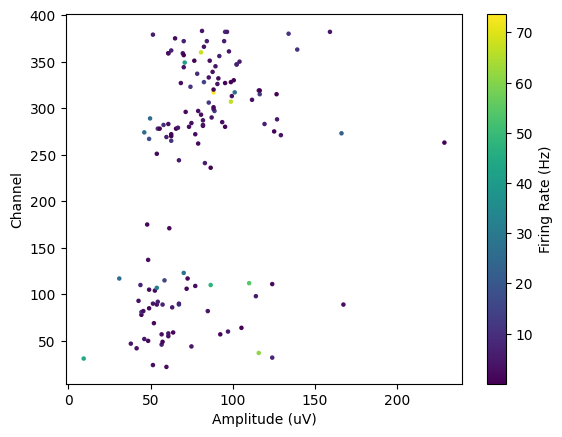

In [22]:
plt.scatter(-metrics[filter]['amplitude_median'], metrics[filter]['depth'], s=5, c = metrics[filter]['firing_rate'])
# add colorbar
plt.colorbar(label='Firing Rate (Hz)')
plt.xlabel('Amplitude (uV)')
plt.ylabel('Channel')

Text(0.5, 0, 'Firing Rate (Hz)')

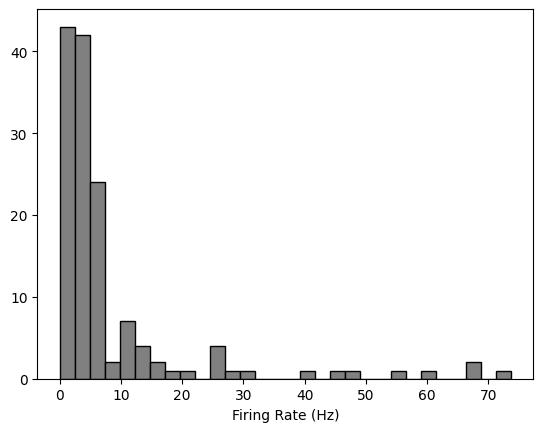

In [24]:
plt.hist(metrics[filter]['firing_rate'], bins=30, color='gray', edgecolor='black')
plt.xlabel('Firing Rate (Hz)')